# Bio Tag Analysis: Slot Filling and Intent Detection

This notebook builds and evaluates models for a spoken-language-understanding task. Each training row contains an utterance, one BIO slot tag per token, and one intent label in the format `word:slot word:slot ... <=> intent`.

The workflow is organized as follows:
1. Load and parse the labelled training data.
2. Explore slot, intent, sequence-length, and vocabulary patterns.
3. Check data quality issues that could bias training or evaluation.
4. Create a leakage-aware train/validation split.
5. Train a baseline intent/slot system with SVM and CRF models.
6. Train and tune a BiLSTM-CRF slot tagger.
7. Generate final predictions for `student_test.txt`.

The final prediction file is written as `A2_Task_2_pred.txt` using the SVM intent classifier and the best BiLSTM-CRF slot model.

### Step 1 - Data Loading

We start with the provided `SLUDataLoader` helper from `templates/data_loader_template.py`. It parses `train.txt` into `(words, slots, intent)` tuples and builds the vocabularies used later by both the classical and neural models.

In [1]:
from templates.data_loader_template import SLUDataLoader
from templates.evaluation_template import SLUEvaluator
from collections import Counter, defaultdict
from typing import List, Tuple, Dict
import numpy as np
import os, re, math, itertools, random
import torch
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import chi2
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
from math import ceil
from wordcloud import WordCloud
import joblib

# Global seed: keeps data splitting, model initialization, and PyTorch training reproducible.
GLOBAL_SEED = 42
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)
torch.manual_seed(GLOBAL_SEED)
torch.cuda.manual_seed_all(GLOBAL_SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [2]:
# Use the same relative path style as the brief recommends
loader = SLUDataLoader(data_dir="./data")  
loader.load_all_data()                     
loader.get_data_stats()
data = loader.train_data

Loading airline dialogue dataset...
Loaded 4478 samples from train.txt
Vocabulary sizes - Words: 869, Slots: 121, Intents: 21
File not found: ./data\valid.txt
Dataset loading completed!

=== Dataset Statistics ===
Training samples: 4478
Validation samples: 0
Test samples: 0
Average sequence length: 11.28
Max sequence length: 46
Min sequence length: 1

Top 5 intents:
  atis_flight: 3309 (73.9%)
  atis_airfare: 385 (8.6%)
  atis_ground_service: 230 (5.1%)
  atis_airline: 139 (3.1%)
  atis_abbreviation: 130 (2.9%)

Top 10 slot labels:
  O: 32066
  B-toloc.city_name: 3919
  B-fromloc.city_name: 3892
  I-toloc.city_name: 987
  B-depart_date.day_name: 785
  B-airline_name: 639
  I-fromloc.city_name: 632
  B-depart_time.period_of_day: 521
  I-airline_name: 379
  B-depart_date.day_number: 355


### Step 2 - Exploratory Data Analysis and Data Quality Checks

#### Slot Distribution

This section checks how much labelled slot information each utterance carries. The `O` tag is ignored in the slot-frequency counts because it means "outside any entity" and would otherwise dominate the distribution without telling us which entity types the model needs to learn.

Top 10 slot tags: [('B-toloc.city_name', 3919), ('B-fromloc.city_name', 3892), ('I-toloc.city_name', 987), ('B-depart_date.day_name', 785), ('B-airline_name', 639), ('I-fromloc.city_name', 632), ('B-depart_time.period_of_day', 521), ('I-airline_name', 379), ('B-depart_date.day_number', 355), ('B-depart_date.month_name', 339)]
Least frequent slots (10):  [('I-meal_description', 1), ('B-return_date.today_relative', 1), ('B-stoploc.airport_name', 1), ('I-time', 1), ('B-time_relative', 1), ('B-state_name', 1), ('I-fare_basis_code', 1), ('B-return_date.day_name', 1), ('B-arrive_date.today_relative', 1), ('I-return_date.today_relative', 2)]
Utterances with 0 slots: 17, 1 slot: 493, 2+ slots: 3968


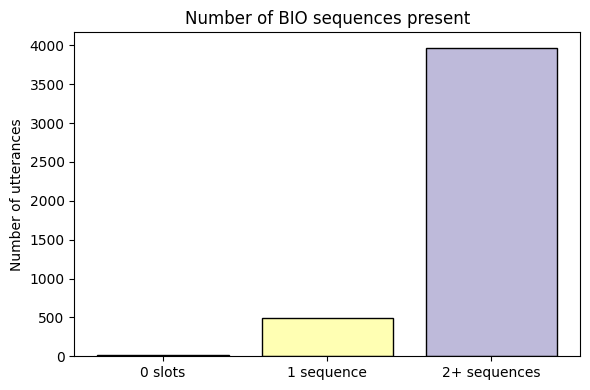

Empty utterances(5 shown) :
Phrase:  ['how', 'many', 'booking', 'classes', 'are', 'there']
Intent:  atis_quantity
Phrase:  ['what', 'airlines', 'are', 'there']
Intent:  atis_airline
Phrase:  ['display', 'all', 'fare', 'codes']
Intent:  atis_airfare
Phrase:  ['what', 'are', 'the', 'prices', 'of', 'these', 'flights']
Intent:  atis_airfare
Phrase:  ['show', 'me', 'the', 'airlines']
Intent:  atis_airline


In [3]:
def slot_distribution(samples):
    """
    Count informative BIO slot labels across a dataset split.

    Args:
        samples: List of (words, slots, intent) tuples.

    Returns:
        slot_counts: frequency of non-"O" slot labels.
        slot_per_utt: number of entity starts ("B-" tags) per utterance.
        empty_slots: utterances that contain no labelled slot entity.
    """
    slot_counts = Counter()
    slot_per_utt = []
    empty_slots = []
    for words, slots, intent in samples:
        # Exclude "O" because it marks non-entity tokens and would hide the informative slot-label distribution.
        slot_counts.update([s for s in slots if s != "O"]) 
        slot_entities = sum(1 for s in slots if s.startswith("B-"))
        slot_per_utt.append(slot_entities)
        if not slot_entities : 
            empty_slots.append((words,slots,intent))
            
    return slot_counts, slot_per_utt, empty_slots

# Display the distribution of meaningful slot labels and entity counts per utterance.
slot_counts, slot_per_utt, empty_slots = slot_distribution(data) 
print("Top 10 slot tags:", slot_counts.most_common(10)) #most frequent
print("Least frequent slots (10): ",slot_counts.most_common()[:-11:-1])#least frequent

#Utterances containing zero, one or two+ 'meaningful' slots
zero = sum(1 for x in slot_per_utt if x == 0) #zero
one = sum(1 for x in slot_per_utt if x == 1) #one
two_plus = sum(1 for x in slot_per_utt if x >= 2) #two+
print(f"Utterances with 0 slots: {zero}, 1 slot: {one}, 2+ slots: {two_plus}")

cats   = ["0 slots", "1 sequence", "2+ sequences"] #NOTE: sequences always start with B, so each B found = one BIO sequence
values = [zero, one, two_plus]
total  = sum(values)

colors = ["#8dd3c7","#ffffb3","#bebada"]
plt.figure(figsize=(6,4))
bars = plt.bar(cats, values, color=colors, edgecolor="black")
plt.ylabel("Number of utterances")
plt.title("Number of BIO sequences present")

plt.tight_layout()
plt.savefig("slots_count_bar.png", dpi=150)
plt.show()

print("Empty utterances(5 shown) :")
for words, slots, intent in empty_slots[:5]:
    print("Phrase: ",words)
    print("Intent: ",intent)

---
#### Observations

- Seventeen utterances contain no labelled slot entities. These examples carry little slot-filling signal, but they are useful negative examples because the model must also learn when no entity is present.
- Most utterances are information dense, with two or more BIO entity sequences.
- The most frequent tags are mostly departure/arrival cities and departure dates. The rarest tags describe more specific concepts such as meals, relative dates, state names, and fare-basis details.

---

#### Sequence Length Analysis and Outliers

Sequence length matters because unusually short or long utterances can reveal parsing problems, unusual language, or cases that may be harder for sequence models. The goal here is diagnostic: identify outliers without removing them unless a clear data-quality issue is found.

Absolute len stats | mean: 11.28 median: 11.00 std: 4.39 min: 1.00 p95: 19.00 max: 46.00


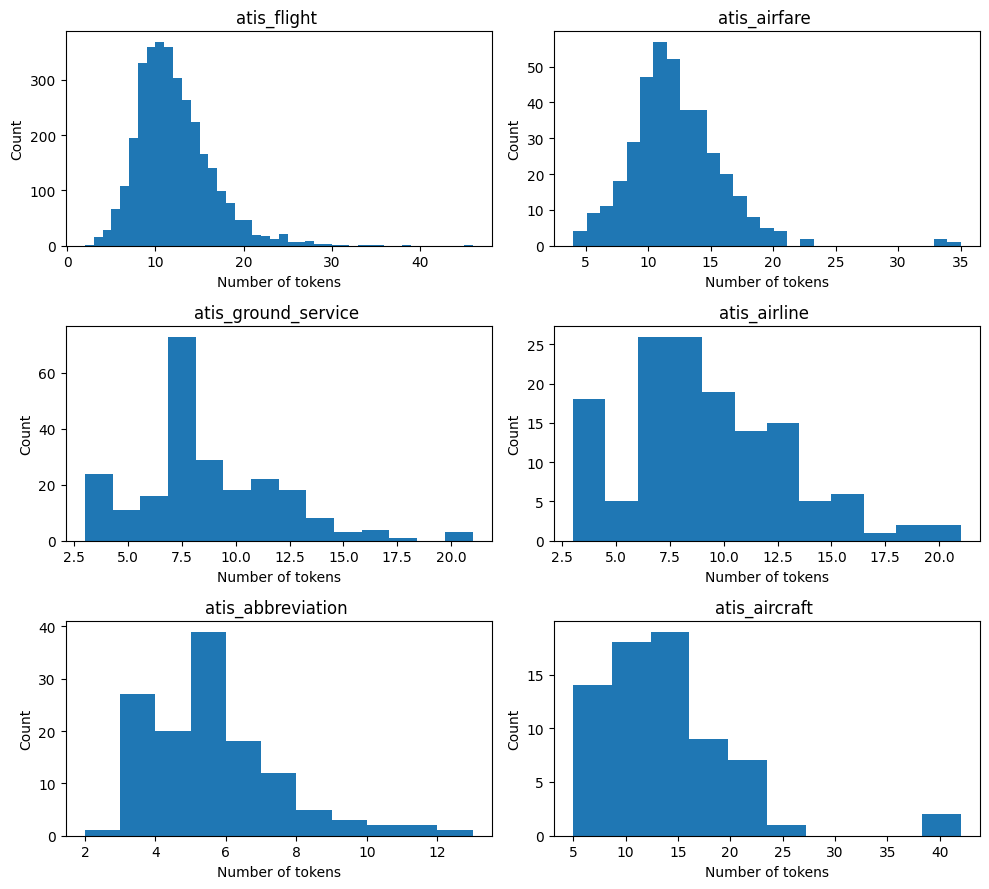

In [4]:
# Absolute sequence-length summary.
def seq_lengths(samples):
    """Return utterance lengths as a NumPy array for summary statistics and plotting."""
    lens = [len(w) for w,_,_ in samples]
    return np.array(lens)

L = seq_lengths(data)
print(f"Absolute len stats | mean: {L.mean():.2f} median: {np.median(L):.2f} std: {L.std():.2f} min: {L.min():.2f} p95: {np.percentile(L, 95):.2f} max: {L.max():.2f}")

# Sequence-length distributions by the most common intents.
# Focus on the six most frequent intents so the plot stays readable.
intent_counts = Counter([i for _,_,i in data]).most_common(6)
top_intents = [it for it, _ in intent_counts]

#Collect lengths
lengths_by_intent = {it: [len(w) for w, s, i in data if i == it] for it in top_intents}

# Create one histogram panel per selected intent.
n = len(top_intents)
cols = 2
rows = math.ceil(n / cols)
fig, axes = plt.subplots(rows, cols, figsize=(10, 3 * rows))
axes = np.atleast_1d(axes).ravel()

#Iterate over top intents
for idx, it in enumerate(top_intents):
    ax = axes[idx]
    lens = lengths_by_intent[it]
    if not lens:
        ax.set_visible(False)
        continue

    # Plot
    ax.hist(lens, bins="auto")
    ax.set_title(f"{it} ")
    ax.set_xlabel("Number of tokens")
    ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

In [5]:
# Flag unusually short and long utterances using the 3rd and 97th percentiles.
p3, p97 = np.percentile(L, 3), np.percentile(L, 97)
outliers_short = [(w,s,i) for (w,s,i) in data if len(w) < p3]
outliers_long  = [(w,s,i) for (w,s,i) in data if len(w) > p97]
print(f"Short outliers: {len(outliers_short)} | Long outliers: {len(outliers_long)}")

Short outliers: 69 | Long outliers: 135


---
**Observations:**
-  For all of the intents in the top 6, the distribution is somewhat gaussian, but most do show quite a strong right tail, indicating skewness. This is reflected in the outliers that we found, mostly being **long outliers** coming from the right side of the plot. Basically, we have a lot of sentences that are much longer than the average
-  Note that these are not necessarily anomalies: since we are gonna extract our features from each single word, the **length of the word doesn't really matter too much in determining the slot of each label**. On the other hand, **it might be important when determining the intent**, as a lot of those very long words might end up being multi-intent sentences, harder to label
-  Either way, we believe that removing them outright would prove detrimental to the slot classification, so we did not remove them.

---

#### Data Quality Checks

Before modelling, we check the labels for problems that could make validation scores misleading or make the model learn inconsistent patterns. In particular, we verify that:

1. BIO tags are valid: an `I-*` tag should continue an existing entity of the same type.
2. No utterance is malformed: words and slots should be present and aligned one-to-one.
3. Exact duplicate utterances do not appear with conflicting intent labels.
4. Near-duplicate utterances with different intents are visible for manual review.

In [6]:
# 1. Check that each BIO tag sequence is valid.
def bio_is_valid(slots: List[str]) -> bool:
    """Return True when every I-tag continues an active entity of the same type."""
    prev_type, prev_tag = None, "O"
    for tag in slots:
        if tag == "O":
            prev_type, prev_tag = None, "O"; continue
        if "-" not in tag: return False
        bio, typ = tag.split("-", 1)
        if bio == "B":
            prev_type, prev_tag = typ, "B"
        elif bio == "I":
            if prev_tag == "O" or prev_type != typ:
                return False
            prev_tag = "I"
        else:
            return False
    return True

invalid_bio_seq = []
for w,s,i in data:
    if not bio_is_valid(s):
        invalid_bio_seq.append((w,s,i))
print("Invalid BIO sequences in TRAIN:", len(invalid_bio_seq))

Invalid BIO sequences in TRAIN: 0


In [7]:
# 2. Check whether any parsed examples are malformed.
def is_malformed(words, slots, intent):
    """Return True for empty examples, word/slot misalignment, or missing intent labels."""
    # Word and slot lengths must match because this is a token-level labelling task.
    if len(words) == 0 or len(words) != len(slots): return True
    if not isinstance(intent, str) or intent.strip() == "": return True
    return False

malformed = [(w,s,i) for (w,s,i) in data if is_malformed(w,s,i)]
print("Malformed entries:", len(malformed))

Malformed entries: 0


In [8]:
# 3. Look for exact-normalized duplicate utterances with different intent labels.
def normalize(words):
    """Normalize an utterance so duplicates can be compared independent of casing/punctuation."""
    # Lowercase and keep only letters, digits, and spaces.
    text = " ".join(words).lower()
    text = re.sub(r"[^a-z0-9\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

groups = defaultdict(set)
examples = defaultdict(list)
for w,s,i in data:
    key = normalize(w)
    groups[key].add(i)
    if len(examples[key]) < 3:
        examples[key].append((w,s,i))

inconsistent = {k:v for k,v in groups.items() if len(v) > 1}
print("Exact-normalized duplicates with different intents:", len(inconsistent))

# Show one conflicting duplicate group, if any, for manual inspection.
peek_key = next(iter(inconsistent)) if inconsistent else None
if peek_key:
    print(peek_key, "->", groups[peek_key], "\nExamples:", examples[peek_key])

Exact-normalized duplicates with different intents: 0


In [9]:
# 4. Use cosine similarity to surface near-duplicate utterances with different intent labels.
# These pairs need manual review because they may be legitimate ambiguity or labelling noise.
sample = [" ".join(w).lower() for w,_,_ in data]
labels = [i for _,_,i in data]
tfidf = TfidfVectorizer(ngram_range=(1,2), min_df=2).fit_transform(sample)
S = cosine_similarity(tfidf)
pairs = []
th = 0.9  # near-duplicate threshold set at 0.9
for a in range(len(sample)):
    for b in range(a+1, len(sample)):
        if S[a,b] >= th and labels[a] != labels[b]:
            pairs.append((a,b,S[a,b], labels[a], labels[b], sample[a], sample[b]))
len(pairs), pairs 

(0, [])

---
**What we observe:**  
Our data seem to be correct on most things:
-  It does not contain any duplicates or near duplicates with different intents
-  It does not contain any invalid BIO sequences
-  It does not contain any malformed entries
---

#### Linguistic and Semantic Analysis

This section looks at the language patterns behind the labels. The goal is to understand what the models will rely on, not to change the data.

We inspect:
- common tokens overall and by intent;
- frequent BIO tag transitions;
- terms that are highly predictive for the most common intents;
- later, out-of-vocabulary words after the train/validation split is created.

In [10]:
def token_counts(samples):
    """Count lowercase tokens for a dataset subset."""
    c = Counter()
    for w,_,_ in samples: c.update([t.lower() for t in w])
    return c

overall_counts = token_counts(data)
print("Top 20 tokens overall:", overall_counts.most_common(20))

# Compare token usage for the most frequent intents.
topN = 5
top_intents = [it for it,_ in Counter([i for _,_,i in data]).most_common(topN)]
per_intent_counts = {it: token_counts([x for x in data if x[2]==it]) for it in top_intents}
{it: per_intent_counts[it].most_common(10) for it in top_intents}
for it in top_intents:
    print(f"\nTop tokens for intent: {it}")
    for tok, cnt in per_intent_counts[it].most_common(10):
        print(f"  {tok:20s} {cnt}")

Top 20 tokens overall: [('to', 3883), ('from', 3343), ('flights', 2188), ('the', 1868), ('on', 1336), ('me', 1137), ('what', 1130), ('flight', 1067), ('boston', 964), ('show', 946), ('san', 908), ('denver', 890), ('a', 815), ('francisco', 780), ('in', 759), ('and', 704), ('atlanta', 670), ('i', 659), ('pittsburgh', 628), ('is', 596)]

Top tokens for intent: atis_flight
  to                   3212
  from                 2747
  flights              2037
  the                  1311
  on                   1155
  flight               956
  me                   908
  show                 774
  boston               746
  san                  725

Top tokens for intent: atis_airfare
  to                   385
  from                 343
  the                  251
  fare                 150
  what                 142
  is                   119
  fares                116
  trip                 104
  round                103
  me                   102

Top tokens for intent: atis_ground_service
  

---
**Observations:**
-  If we look at the **overall best tokens**, they look **very similar to atis_flight tokens**. That is because atis_flight is by far the most occuring intent.
-  **to** and **from** are tokens present across many different intents, and therefore do not seem to provide much predictive power

---

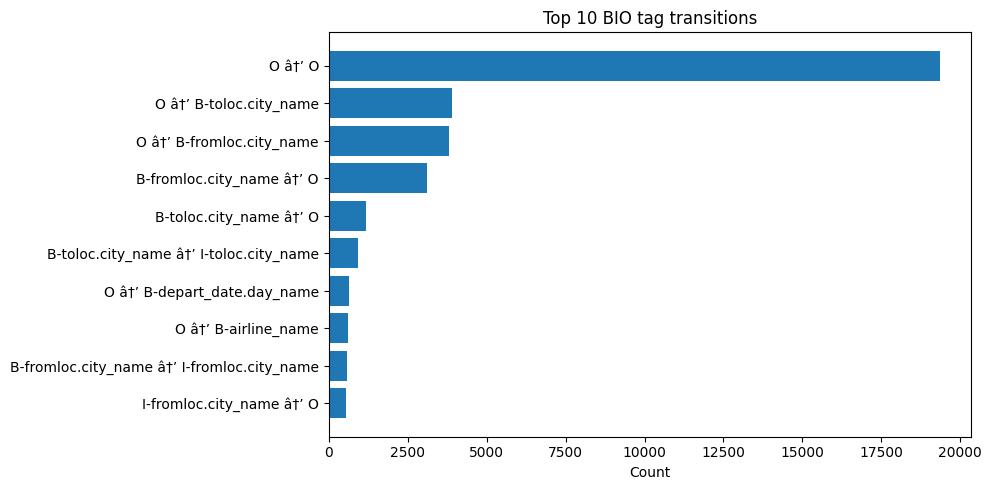

In [11]:
# Build a BIO transition matrix to see which tag-to-tag moves are common.
tags = sorted({tag for _,s,_ in data for tag in s})
idx = {t:i for i,t in enumerate(tags)}
M = np.zeros((len(tags), len(tags)), dtype=int)

for _, s, _ in data:
    for a, b in zip(s[:-1], s[1:]):
        M[idx[a], idx[b]] += 1

def plot_top_transitions(M, tags, k=20 , figsize=(10,5)):
    """
    Plot the most frequent adjacent BIO tag transitions.

    M: transition count matrix where rows are current tags and columns are next tags.
    tags: tag names aligned with the matrix indices.
    k: number of transitions to display.
    """
    M_use = M.copy().astype(float)

    pairs = []
    for i, a in enumerate(tags):
        for j, b in enumerate(tags):
            v = M_use[i, j]
            if v > 0:
                pairs.append((f"{a} â†’ {b}", v))

    # Keep only the most frequent transitions so rare transitions do not overwhelm the chart.
    pairs.sort(key=lambda x: x[1], reverse=True)
    top = pairs[:k]

    labels = [p[0] for p in top][::-1]
    vals   = [p[1] for p in top][::-1]

    plt.figure(figsize=figsize)
    plt.barh(labels, vals)
    plt.xlabel("Count")
    plt.title(f"Top {k} BIO tag transitions")
    plt.tight_layout()
    plt.show()

plot_top_transitions(M, tags, k=10)   # top-10 by count

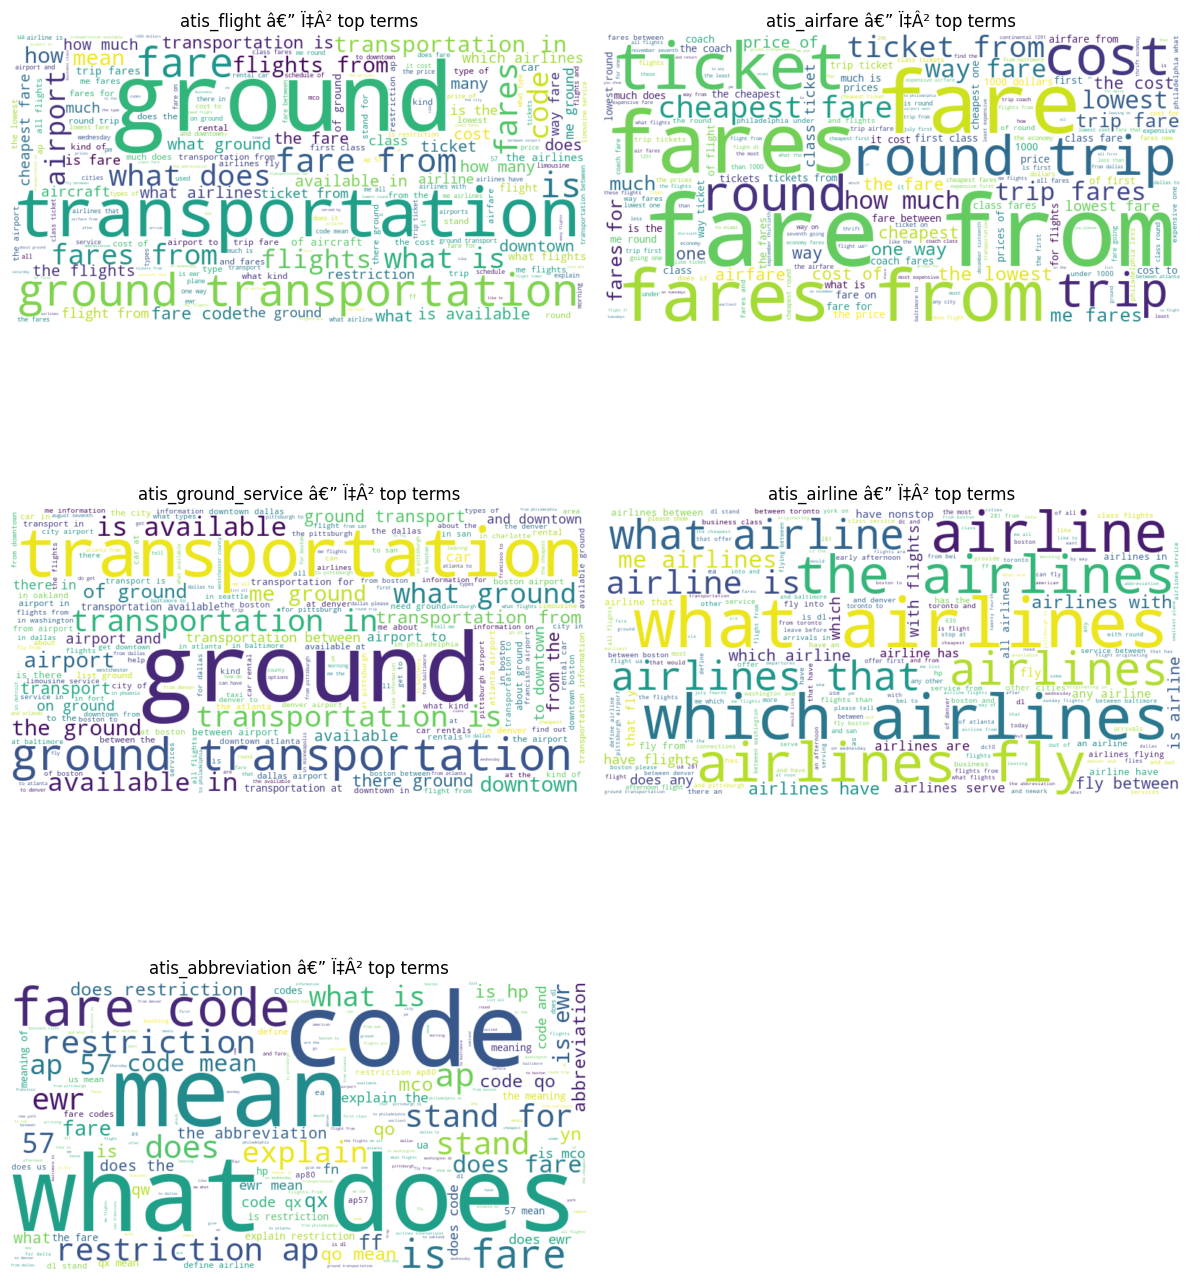

In [12]:
# Visualize words and phrases that are most predictive for the five most common intents.
texts = [" ".join(w).lower() for w,_,_ in data]
y = np.array([i for _,_,i in data])

# Vectorize unigrams and bigrams while dropping very rare terms.
tfidf = TfidfVectorizer(ngram_range=(1,2), min_df=3)
X = tfidf.fit_transform(texts)
terms = np.array(tfidf.get_feature_names_out())

top_intents = [it for it,_ in Counter(y).most_common(5)]

def chi2_scores_for_intent(intent):
    """Return chi-square scores that measure how strongly each term signals one intent."""
    mask = (y == intent).astype(int)
    chi, _ = chi2(X, mask)
    # Convert scores into a frequency-like dictionary for WordCloud.
    scores = {t: float(s) for t, s in zip(terms, chi) if s > 0}
    return scores

cols = 2
rows = (len(top_intents) + cols - 1) // cols
plt.figure(figsize=(12, 5*rows))

for k, intent in enumerate(top_intents):
    freqs = chi2_scores_for_intent(intent)
    # Drop common stopwords so domain-specific intent words stand out.
    for sw in ["the", "a", "an", "to", "from", "on", "in", "of", "and", "or"]:
        freqs.pop(sw, None)

    wc = WordCloud(width=800, height=400, background_color="white", collocations=False)
    wc = wc.generate_from_frequencies(freqs)

    ax = plt.subplot(rows, cols, k+1)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(f"{intent} â€” Ï‡Â² top terms")

plt.tight_layout()
plt.show()

---
**Observations:**
- **atis_flight intent** seem to be **more generic** when compared to the other ones, as the tags that lead to atis_flight prediction seem to also be the tags that have strong predictive power for airfare or ground service.
- This might indicate that the atis_flight intent often co-occurs with other intents such as airfare and ground service
- What this tells us is that the model might have issues distinguishing between ground service/ airfare and flight queries

---

### Step 3 - Leakage-Aware Train/Validation Split

The split is intent-stratified so the validation set reflects the training intent distribution. It is also duplicate-aware: exact duplicate examples are grouped before splitting so that the same utterance cannot appear in both train and validation.

In [13]:
def stratified_group_split_with_singletons(
    samples, test_size=0.2, random_state=42,
    key_mode="text+intent+slots"
):
    """
    Create a leakage-aware, intent-stratified train/validation split.

    Duplicate examples are grouped before splitting so the same utterance cannot appear
    in both train and validation. Rare intents are kept in training because there are
    too few groups to split them reliably while preserving intent balance.

    Args:
        samples: List of (words, slots, intent) tuples.
        test_size: Validation proportion.
        random_state: Reproducibility seed.
        key_mode: Strictness of the duplicate grouping key.

    Returns:
        train_part, valid_part: Lists of samples for model training and validation.
    """

    def canon_text(words):
        # Normalize text before grouping duplicates.
        return " ".join(words).strip().lower()

    def key_for(w, s, i):
        t = canon_text(w)
        if key_mode == "text":
            return (t,)
        elif key_mode == "text+intent":
            return (t, i)
        else:  # "text+intent+slots"
            return (t, i, tuple(s))

    # Group identical samples first to prevent duplicate leakage across the split.
    groups = defaultdict(list)
    for idx, (w, s, i) in enumerate(samples):
        k = key_for(w, s, i)
        groups[k].append(idx)

    group_keys = list(groups.keys())
    # Assign one intent label per group for stratification.
    group_intents = []
    for k in group_keys:
        # all items in a group should share the same intent by construction
        any_idx = groups[k][0]
        group_intents.append(samples[any_idx][2])

    # Separate rare intents from intents that can be safely stratified.
    intent_group_counts = Counter(group_intents)
    min_needed_groups = max(2, ceil(1 / test_size))  # need enough groups to place at least one in validation
    rare_intents = {lbl for lbl, c in intent_group_counts.items() if c < min_needed_groups}

    keep_train_keys = [k for k, it in zip(group_keys, group_intents) if it in rare_intents]
    strat_keys      = [k for k, it in zip(group_keys, group_intents) if it not in rare_intents]
    strat_key_set = set(strat_keys)
    strat_labels = [it for k, it in zip(group_keys, group_intents) if k in strat_key_set]

    # Stratify groups, not raw samples, so duplicates remain together.
    if strat_keys:
        tr_keys, va_keys = train_test_split(
            strat_keys, test_size=test_size, random_state=random_state, stratify=strat_labels
        )
    else:
        tr_keys, va_keys = [], []

    # Keep rare-intent groups in train so the model still sees those labels.
    tr_keys = list(tr_keys) + keep_train_keys

    # Expand selected group keys back to sample indices.
    train_idx = [i for k in tr_keys for i in groups[k]]
    valid_idx = [i for k in va_keys for i in groups[k]]

    train_part = [samples[i] for i in train_idx]
    valid_part = [samples[i] for i in valid_idx]

    # Shuffle train for randomness while leaving validation order stable for inspection.
    rng = np.random.default_rng(random_state)
    rng.shuffle(train_part)

    # Print split diagnostics so the data-partition choices are transparent.
    dup_count = sum(len(v) for v in groups.values()) - len(groups)
    print(f"Total samples: {len(samples)} | Unique groups: {len(groups)} | Duplicates collapsed: {dup_count}")
    print(f"Test size: {test_size} | min_needed_groups per stratified intent: {min_needed_groups}")
    print(f"Rare intents kept only in TRAIN : {sorted(list(rare_intents))}")
    print(f"Final split -> Train: {len(train_part)} | Valid: {len(valid_part)}")
    
    return train_part, valid_part

train_part, valid_part = stratified_group_split_with_singletons( samples=data, test_size=0.20, random_state=42, key_mode="text+intent+slots" )

Total samples: 4478 | Unique groups: 4190 | Duplicates collapsed: 288
Test size: 0.2 | min_needed_groups per stratified intent: 5
Rare intents kept only in TRAIN : ['atis_aircraft;atis_flight;atis_flight_no', 'atis_airline;atis_flight_no', 'atis_cheapest', 'atis_ground_service;atis_ground_fare', 'atis_restriction']
Final split -> Train: 3579 | Valid: 899


In [14]:
# Build word/intent vocabularies from train only; validation words remain true OOVs.
loader.train_data = train_part
loader.valid_data = valid_part
loader.build_vocabularies(loader.train_data)

# Validation may contain rare slot labels that did not appear in the training split.
# Add those labels only for encoding/evaluation so validation can be scored safely.
validation_slots = sorted({slot for _, slots, _ in loader.valid_data for slot in slots})
missing_valid_slots = [slot for slot in validation_slots if slot not in loader.slot_vocab]
for slot in missing_valid_slots:
    loader.slot_vocab[slot] = len(loader.slot_vocab)
loader.id_to_slot = {v: k for k, v in loader.slot_vocab.items()}

print("Validation-only slot labels added to slot vocab:", missing_valid_slots)

Vocabulary sizes - Words: 801, Slots: 114, Intents: 21
Validation-only slot labels added to slot vocab: ['B-return_date.day_name', 'B-state_name', 'B-stoploc.airport_name', 'B-time', 'B-time_relative', 'I-depart_time.time_relative', 'I-time']


---
**Intent distribution and stratified split**

The custom split creates an 80/20 train/validation split while protecting against two common evaluation issues:

1. **Duplicate leakage:** exact duplicate examples stay together so the validation set does not contain utterances the model effectively saw during training.
2. **Class imbalance:** stratifying by intent keeps common intent proportions similar across train and validation.
3. **Rare intent handling:** intents with too few groups to stratify are kept in training so the model still has a chance to learn them.

This avoids overly optimistic validation scores from duplicate leakage and overly pessimistic scores from a validation fold that accidentally overrepresents rare classes. Cross-validation was not used because the BiLSTM-CRF model is relatively expensive to train, and a carefully stratified holdout split is sufficient for this assignment workflow.

**Important bias note:** keeping rare intents only in training can make validation slightly optimistic for those labels. The tradeoff is intentional here because the model still needs exposure to rare labels that may appear in the hidden test set.

---

In [15]:
# OOV: words in valid not seen in train
train_vocab = set(t.lower() for w,_,_ in train_part for t in w)
valid_vocab = set(t.lower() for w,_,_ in valid_part for t in w)
oov_valid = sorted(valid_vocab - train_vocab)
print("OOV tokens in validation:", len(oov_valid))
oov_valid[:30]

OOV tokens in validation: 68


['100',
 '1200',
 '1222',
 '150',
 '163',
 '3357',
 '345',
 '352',
 '445',
 '497766',
 '505',
 '515',
 '615',
 '730',
 '810',
 '98',
 'able',
 'afternoons',
 'america',
 'beginning',
 'begins',
 'belong',
 'bna',
 'charges',
 'continuing',
 'designate',
 'directly',
 "doesn't",
 'eye',
 'gets']

---
**Observations:**
-  There are 65 tokens that are present in validation while not present in training. Such tokens cannot be recognised and are gonna be flagged as "UNK" in our code.
-  Most of these tokens as very specific, such as a **specific value** (734 for instance) or a **specific place** (arizona)

---

### Step 4 - Modelling

#### Model 1 - Baseline CRF/SVM System

The first modelling stage uses two classical models:
- a CRF sequence tagger for BIO slot prediction;
- a linear SVM text classifier for intent prediction.

#### Feature Engineering for CRF/SVM Models

In [16]:
import sklearn_crfsuite
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

# Define interpretable token and context features for the CRF slot tagger.
def word2features(sent, i):
    """Build CRF features for token i using the token itself and one-token context."""
    w = sent[i]; wl = w.lower()
    feats = {
        'bias': 1.0,
        'w.lower': wl,
        'w[:2]': wl[:2],
        'w[:3]': wl[:3],
        'w[-3:]': wl[-3:], 
        'w[-2:]': wl[-2:],
        'w.isupper': w.isupper(),
        'w.istitle': w.istitle(), 
        'w.isdigit': w.isdigit(),
    }
    # Mark the beginning of the sequence, otherwise add one-token lookback context.
    if i == 0: feats['BOS'] = True
    else:
        p = sent[i-1]
        feats.update({'prev_1_w.lower': p.lower(), 'prev_1_w.istitle': p.istitle(), 'prev_1_w.isupper': p.isupper()})

    # Mark the end of the sequence, otherwise add one-token lookahead context.
    if i == len(sent)-1: feats['EOS'] = True
    else:
        n = sent[i+1]
        feats.update({'next_1_w.lower': n.lower(), 'next_1_w.istitle': n.istitle(), 'next_1_w.isupper': n.isupper()}) 
    return feats

def sent2features(words): return [word2features(words, i) for i in range(len(words))]
def sent2slots(slots): return slots
def sent2text(words): return " ".join(words)

---
**Features used**

The CRF receives token-level features that describe each word and a small amount of local context.

**Per-token features:**
- a bias feature, which gives the CRF a baseline signal;
- lowercase token text;
- first and last character n-grams;
- capitalization and digit flags.

**Across-token features:**
- beginning-of-sequence and end-of-sequence flags;
- one-token lookback and lookahead context.

These features are intentionally simple and interpretable, which makes the CRF a useful baseline before moving to a neural sequence model.

---

#### CRF/SVC Model evaluation

In [17]:
# Model evaluation: Support Vector Machine for intent, CRF for the slot prediction
X_slots_tr = [sent2features(w) for w,s,i in train_part]
y_slots_tr = [sent2slots(s) for w,s,i in train_part]
X_slots_va = [sent2features(w) for w,s,i in valid_part]
y_slots_va = [sent2slots(s) for w,s,i in valid_part]

X_txt_tr = [sent2text(w) for w,s,i in train_part]
y_int_tr = [i for w,s,i in train_part]
X_txt_va = [sent2text(w) for w,s,i in valid_part]
y_int_va = [i for w,s,i in valid_part]

crf = sklearn_crfsuite.CRF(algorithm='lbfgs', c1=0.1, c2=0.1, max_iterations=100, all_possible_transitions= True)
crf.fit(X_slots_tr, y_slots_tr)


intent_clf = Pipeline([('tfidf', TfidfVectorizer(ngram_range=(1,2), min_df=1)),
                       ('svm', LinearSVC(C=1.0))])
intent_clf.fit(X_txt_tr, y_int_tr)

#Evaluate

y_true_slots_ids = [[loader.slot_vocab[tag] for tag in seq] for seq in y_slots_va]
y_pred_slots_ids = [[loader.slot_vocab[tag] for tag in seq] for seq in crf.predict(X_slots_va)]
y_true_int_ids = [loader.intent_vocab[lbl] for lbl in y_int_va]
y_pred_int_ids = [loader.intent_vocab[lbl] for lbl in intent_clf.predict(X_txt_va)]
lengths_va = [len(seq) for seq in y_slots_va]

evaluator = SLUEvaluator(loader.slot_vocab, loader.intent_vocab)
results_crf = evaluator.evaluate_model(y_true_intents=y_true_int_ids, y_pred_intents=y_pred_int_ids,
                                       y_true_slots=y_true_slots_ids, y_pred_slots=y_pred_slots_ids,
                                       lengths=lengths_va, verbose=True)
results_crf
print("---------------------") #just to avoid showing the output of results_crf twice

=== Evaluation Results ===
Intent Accuracy: 0.9611
Slot Precision:  0.6873
Slot Recall:     0.6734
Slot F1:         0.6700
Entity F1:       0.9351
---------------------


---

**Results obtained:**

The model already performs at a reasonable level, with an **intent accuracy of 0.96**, and **slot F1** of:
-  **0.72 for tokens**
-  **0.89 for entities as a whole**

---

#### Model 2 - BiLSTM-CRF Slot Tagger

The second slot model combines a bidirectional LSTM encoder with a CRF decoder. The BiLSTM learns contextual token representations, while the CRF chooses the most consistent global BIO tag sequence.

##### Data preparation

In [18]:
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

# Special-token IDs used for padding and unknown words.
PAD_WORD_ID = loader.word_vocab.get("<PAD>", 0)
UNK_WORD_ID = loader.word_vocab.get("<UNK>", 1)

# Slot padding uses 0; masks and lengths prevent padding from affecting loss/metrics.
PAD_SLOT_ID = 0

tag2id = loader.slot_vocab   
id2tag = loader.id_to_slot        
n_tags  = len(tag2id)
n_words = len(loader.word_vocab)

class SlotDataset(Dataset):
    """Expose parsed SLU samples as PyTorch tensors for slot tagging."""
    def __init__(self, samples):
        self.samples = samples
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        w, s, intent = self.samples[idx]
        w_ids = torch.as_tensor(loader.words_to_ids(w), dtype=torch.long)
        s_ids = torch.as_tensor(loader.slots_to_ids(s), dtype=torch.long)
        L     = torch.tensor(len(w), dtype=torch.long)
        return {"words": w_ids, "slots": s_ids, "length": L}

def collate_fn(batch):
    """Pad one batch dynamically and create a mask for real (non-padding) tokens."""
    # Dynamic padding keeps batches compact while still giving the model rectangular tensors.
    max_len = max(int(x["length"]) for x in batch) # longest utterance in this batch
    B = len(batch)
    words = torch.full((B, max_len), PAD_WORD_ID, dtype=torch.long) # padded word-id matrix
    slots = torch.full((B, max_len), PAD_SLOT_ID, dtype=torch.long)
    lengths = torch.tensor([int(x["length"]) for x in batch], dtype=torch.long) # original lengths for masking/evaluation
    mask = torch.zeros((B, max_len), dtype=torch.bool)
    for i, x in enumerate(batch):
        # Fill real tokens up to length L; remaining positions stay as padding.
        L = int(x["length"])
        words[i, :L] = x["words"]
        slots[i, :L] = x["slots"]
        mask[i, :L]  = True
    return {"words": words, "slots": slots, "lengths": lengths, "mask": mask}

train_ds = SlotDataset(train_part)
valid_ds = SlotDataset(valid_part)

train_dl = DataLoader(train_ds, batch_size=64, shuffle=True,  collate_fn=collate_fn)
valid_dl = DataLoader(valid_ds, batch_size=128, shuffle=False, collate_fn=collate_fn)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

**Data preparation**

- Tokens and slot tags are converted into integer IDs so they can be used by PyTorch.
- `collate_fn()` pads each batch to that batch's longest utterance. Dynamic padding avoids wasting computation on the global maximum sequence length.
- Boolean masks identify real tokens versus padding so the CRF loss and decoder ignore padded positions.
- `DataLoader` applies batching and calls the collate function for both training and validation.

##### Model Definition

In [19]:
from torchcrf import CRF

# Pair a BiLSTM encoder with a CRF decoder for globally consistent BIO tag sequences.
class BiLSTMCRF(nn.Module):
    """BiLSTM-CRF sequence tagger for slot filling."""
    # emb_dim, hidden, num_layers, and dropout are tuned later.
    def __init__(self, vocab_size, tag_size, emb_dim=100, hidden=200, num_layers=1, dropout=0.3, pad_idx=PAD_WORD_ID):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx) # learned domain-specific token embeddings
        self.dropout = nn.Dropout(dropout)
        
        # The bidirectional LSTM gives each token left and right context.
        self.lstm = nn.LSTM(
            input_size=emb_dim,
            hidden_size=hidden,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout = dropout if num_layers > 1 else 0.0 # PyTorch applies LSTM dropout only between stacked layers
        )
        self.fc = nn.Linear(hidden * 2, tag_size)   # token-level emission scores for the CRF
        self.crf = CRF(tag_size, batch_first=True)

        # Initialize the final projection for stable early training.
        nn.init.xavier_uniform_(self.fc.weight)
        nn.init.zeros_(self.fc.bias)

    def emissions(self, x):
        # Convert word IDs into CRF emission scores.
        # x: (B, T) word ids
        emb = self.embedding(x)               # (B, T, E)
        out, _ = self.lstm(emb)               # (B, T, 2H)
        out = self.dropout(out)               # dropout after final RNN layer
        logits = self.fc(out)                 # (B, T, tag_size)
        return logits

    def forward(self, x, tags=None, mask=None):
        """
        Train when gold tags are provided; decode best BIO paths when tags are omitted.
        """
        logits = self.emissions(x)
        if tags is not None:
            # torchcrf expects True for real tokens and False for padding.
            nll = -self.crf(logits, tags, mask=mask, reduction='mean')
            return nll
        else:
            paths = self.crf.decode(logits, mask=mask)  # List[List[int]]
            return paths

**Model design**

- The embedding layer is learned from this airline-query dataset. This is reasonable because the vocabulary is domain-specific and the dataset uses short command-like utterances.
- The bidirectional LSTM reads each utterance from left to right and right to left, which helps the model use both previous and future context for each token.
- The linear layer converts each contextual token representation into scores for every possible slot tag.
- The CRF layer models tag transitions, which helps avoid invalid or unlikely BIO sequences when decoding the final slot labels.

##### Model training and evaluation

In [20]:
model = BiLSTMCRF(vocab_size=n_words, tag_size=n_tags, emb_dim=100, hidden=200, dropout=0.3).to(device) #device has been defined before
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-4)

def eval_on_loader(model, dl, slot_vocab, intent_vocab):
    """Evaluate slot predictions from a DataLoader while ignoring padded positions."""
    
    model.eval()  # eval-time behavior (e.g., disable dropout)
    all_true, all_pred, all_len = [], [], []
    with torch.no_grad(): # no gradient tracking during validation
        for batch in dl:
            words = batch["words"].to(device)
            slots = batch["slots"].to(device)
            mask  = batch["mask"].to(device)

            pred_paths = model(words, tags=None, mask=mask)  # omit tags to trigger CRF decoding
            lens = batch["lengths"].tolist()
            for i, L in enumerate(lens):
                all_true.append(slots[i, :L].tolist()) # keep only real, non-padded tokens
                all_pred.append(pred_paths[i][:L])
                all_len.append(L)

    evaluator = SLUEvaluator(slot_vocab, intent_vocab)
    dummy = [0]*len(all_true) # dummy intents because this model evaluates slot filling only
    results = evaluator.evaluate_model(dummy, dummy, all_true, all_pred, all_len, verbose=False)
    results.pop("intent_accuracy", None)
    return results

# Early-stopping state.
EPOCHS = 50
patience = 3 # stop after this many validation checks without improvement
best_f1 = -1  
bad = 0
best_state = None
best_info  = None
best_epoch = -1

# Train until max epochs or early stopping.
for epoch in range(1, EPOCHS+1):
    model.train()
    total_loss = 0.0
    for batch in train_dl:
        words = batch["words"].to(device)
        slots = batch["slots"].to(device)
        mask  = batch["mask"].to(device)

        loss = model(words, tags=slots, mask=mask) # providing tags makes forward() return CRF negative log-likelihood
        optimizer.zero_grad() #clear gradients from previous batches
        loss.backward() # compute gradients
        nn.utils.clip_grad_norm_(model.parameters(), 5.0) # clip gradients to stabilize RNN training
        optimizer.step() #updates weights
        total_loss += loss.item()

    res_val = eval_on_loader(model, valid_dl, loader.slot_vocab, loader.intent_vocab)
    
    # Pull out the slot metrics used for logging and model selection.
    entity_f1 = float(res_val.get("entity_f1", float('nan')))
    token_prec = float(res_val.get('slot_precision', float('nan')))
    token_f1 = float(res_val.get('slot_f1', float('nan')))
    token_recall = float(res_val.get('slot_recall', float('nan')))
    val_f1 = entity_f1 # choose entity F1 because complete spans matter more than token-only matches
    
    # Print one compact progress line per epoch.
    print(f"Epoch {epoch:02d} | train_loss={total_loss/len(train_dl):.2f} | token_f1= {token_f1:.2f} | entity_F1={entity_f1:.2f} | token_precision={token_prec:.2f} | token_recall= {token_recall:.2f}")

    # Save the best checkpoint and stop when validation entity F1 plateaus.
    if val_f1 > best_f1 + 1e-4:
        best_f1 = val_f1
        best_epoch = epoch
        bad = 0
        best_state = {k: v.detach().cpu().clone() for k,v in model.state_dict().items()}
        best_info = {
            "epoch": best_epoch,
            "metrics": {
                "token_f1": token_f1,
                "token_precision": token_prec,
                "token_recall": token_recall,
                "entity_f1": entity_f1
            }
        }
    else:
        bad += 1
        if bad >= patience:
            print(f"Early stop at epoch {best_epoch} (best entity-F1={best_f1:.4f})")
            break

metrics = best_info["metrics"]
print(f"=== Results (EPOCH: {best_epoch}) === ")
print(f"Best Entity-F1: {best_f1:.4f} ")
print(f"Token-F1: {metrics['token_f1']:.4f} ")
print(f"Token_Precision : {metrics['token_precision']:.4f} ")
print(f"Token_Recall : {metrics['token_recall']:.4f} ")

# Restore and save the best validation checkpoint.
if best_state is not None:
    model.load_state_dict(best_state)
    torch.save(model.state_dict(), "bilstm_crf_slots.pt")

Epoch 01 | train_loss=13.60 | token_f1= 0.30 | entity_F1=0.84 | token_precision=0.34 | token_recall= 0.29


Epoch 02 | train_loss=2.14 | token_f1= 0.56 | entity_F1=0.92 | token_precision=0.63 | token_recall= 0.54


Epoch 03 | train_loss=0.95 | token_f1= 0.67 | entity_F1=0.94 | token_precision=0.72 | token_recall= 0.65


Epoch 04 | train_loss=0.53 | token_f1= 0.72 | entity_F1=0.96 | token_precision=0.74 | token_recall= 0.71


Epoch 05 | train_loss=0.30 | token_f1= 0.74 | entity_F1=0.96 | token_precision=0.77 | token_recall= 0.72


...

Epoch 10 | train_loss=0.04 | token_f1= 0.77 | entity_F1=0.96 | token_precision=0.79 | token_recall= 0.76


Epoch 11 | train_loss=0.03 | token_f1= 0.78 | entity_F1=0.97 | token_precision=0.80 | token_recall= 0.77


Epoch 12 | train_loss=0.02 | token_f1= 0.77 | entity_F1=0.96 | token_precision=0.79 | token_recall= 0.76


Epoch 13 | train_loss=0.02 | token_f1= 0.77 | entity_F1=0.97 | token_precision=0.80 | token_recall= 0.75


Epoch 14 | train_loss=0.02 | token_f1= 0.78 | entity_F1=0.97 | token_precision=0.81 | token_recall= 0.77
Early stop at epoch 11 (best entity-F1=0.9662)
=== Results (EPOCH: 11) === 
Best Entity-F1: 0.9662 
Token-F1: 0.7799 
Token_Precision : 0.8017 
Token_Recall : 0.7714 


---
**Training and evaluation**

- `eval_on_loader()` adapts the provided `SLUEvaluator` to the slot-only BiLSTM-CRF setting.
- The training loop uses gradient clipping for stability and early stopping when validation entity F1 stops improving.
- Entity F1 is the main selection metric because it rewards complete entity spans, not just individual token-level matches.

**Initial untuned result**

Even before tuning, the BiLSTM-CRF improves substantially over the baseline CRF for slot prediction. Intent classification is already strong with the SVM model, so the neural model is used only for slot filling.

---

#### BiLSTM-CRF Hyperparameter Tuning

In [21]:
import itertools, math, random, time
import torch
from torch import nn
from copy import deepcopy

def set_seed(seed: int):
    """Set random seeds so repeated tuning runs are easier to compare."""
    random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

def train_one_run(config, train_samples, valid_samples, loader, device):
    """
    Train and validate one BiLSTM-CRF hyperparameter configuration.

    The function owns the model, optimizer, validation loop, early stopping state,
    and best checkpoint for a single tuning run.
    """

    train_ds = SlotDataset(train_samples)
    valid_ds = SlotDataset(valid_samples)

    train_dl = torch.utils.data.DataLoader(
        train_ds,
        batch_size=config["batch_size"],
        shuffle=True,
        collate_fn=collate_fn,
    )
    valid_dl = torch.utils.data.DataLoader(valid_ds, batch_size=128, shuffle=False, collate_fn=collate_fn)

    # Build a fresh model for this hyperparameter configuration.
    n_words = len(loader.word_vocab)
    n_tags  = len(loader.slot_vocab)

    model = BiLSTMCRF(
        vocab_size=n_words,
        tag_size=n_tags,
        emb_dim=config["emb_dim"],
        hidden=config["hidden"],
        num_layers=config["num_layers"],
        dropout=config["dropout"],
        pad_idx=loader.PAD_ID
    ).to(device)

    # Configure optimizer and optional learning-rate scheduler.
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=config["lr"],
        weight_decay=config["weight_decay"]
    )
    scheduler = None
    if config.get("use_plateau_scheduler", False):
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode="max", factor=0.5, patience=2, verbose=False
        )

    # Training loop with early stopping on validation entity F1.
    max_epochs = config["max_epochs"]
    patience   = config["patience"]
    best_f1    = -1.0
    best_state = None
    bad_epochs = 0

    for epoch in range(1, max_epochs + 1):
        model.train()
        total_loss = 0.0
        for batch in train_dl:
            words = batch["words"].to(device)
            slots = batch["slots"].to(device)
            mask  = batch["mask"].to(device)

            loss = model(words, tags=slots, mask=mask)     # scalar NLL
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 5.0)
            optimizer.step()
            total_loss += loss.item()

        # Validate after each epoch using the same slot metrics as the untuned model.
        res_val = eval_on_loader(model, valid_dl, loader.slot_vocab, loader.intent_vocab)
        
        # Pull out the metrics needed for logging, ranking, and early stopping.
        entity_f1 = float(res_val.get("entity_f1", float('nan')))
        token_prec = float(res_val.get('slot_precision', float('nan')))
        token_f1 = float(res_val.get('slot_f1', float('nan')))
        token_recall = float(res_val.get('slot_recall', float('nan')))
        val_f1 = entity_f1 # choose entity F1 because the model must recover complete slot spans

        if scheduler is not None:
            scheduler.step(val_f1)

        # Early-stopping bookkeeping for this configuration.
        if val_f1 > best_f1 + 1e-4:
            best_f1 = val_f1
            best_epoch = epoch
            bad_epochs = 0
            # Clone the best state to CPU to avoid growing GPU memory across tuning runs.
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            best_info = {
                "epoch": best_epoch,
                "metrics": {
                    "token_f1": token_f1,
                    "token_precision": token_prec,
                    "token_recall": token_recall,
                    "entity_f1": entity_f1
                }
            }
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                break

    return {
        "best_entity_f1": best_f1,
        "best_token_f1": best_info["metrics"]["token_f1"] if best_state is not None else None,
        "best_info": best_info if best_state is not None else None,
        "best_state": best_state   # saved weights for the winning config
    }

---
**What this tuning loop does**

`train_one_run()` trains one BiLSTM-CRF configuration at a time, evaluates it on the validation set, keeps the best checkpoint for that run, and returns the metrics needed to compare configurations.

---

In [22]:
import random
def sample_config(seed=42):
    """Sample one random hyperparameter configuration from the search space."""
    rng = random.Random(seed)
    return {
        "emb_dim": rng.choice([100, 200]),
        "hidden": rng.choice([128, 200, 256]),
        "num_layers": rng.choice([1, 2]),
        "dropout": rng.uniform(0.15, 0.45),   # continuous
        "lr": 10 ** rng.uniform(-3.5, -2.5),  # log-uniform ~ [3e-4, 3e-3]
        "weight_decay": rng.choice([0.0, 1e-4, 3e-4]),
        "batch_size": rng.choice([32, 64]),
        "max_epochs": 30,
        "patience": 3,
        "use_plateau_scheduler": False,
    }

def random_iter_continuous(n=10, seed=42):
    """Yield n reproducible random configurations for the tuning loop."""
    rng = random.Random(seed)
    for i in range(n):
        yield sample_config(seed=rng.randint(0, 10**9))

---
**Random hyperparameter search**

A small random search is used instead of an exhaustive grid because each BiLSTM-CRF training run is relatively expensive. Random search gives coverage across the parameter ranges while keeping runtime manageable.

**Tunable hyperparameters:**
- *emb_dim*: learned embedding size for each token;
- *hidden*: LSTM hidden size per direction;
- *num_layers*: number of stacked LSTM layers;
- *dropout*: regularization applied during training to reduce overfitting;
- *lr*: learning rate for AdamW;
- *weight_decay*: AdamW L2-style regularization;
- *batch_size*: number of examples per training update.

---

In [23]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Reuse the prepared split and vocabularies so tuning is evaluated on the same validation set.
# The word vocabulary is built from training data to keep validation realistic.
train_samples = loader.train_data
valid_samples = loader.valid_data

results = []
run_id = 0


for cfg in random_iter_continuous(n=10, seed=123):
    run_id += 1
    t0 = time.time()
    set_seed(123)
    out = train_one_run(cfg, train_samples, valid_samples, loader, device)
    entity_result = out["best_entity_f1"]
    token_result = out["best_token_f1"]
    state = out["best_state"]
    info = out["best_info"]
    dt = time.time() - t0

    rec = deepcopy(cfg)
    rec.update({
        "run_id": run_id,
        "entity_f1": entity_result,
        "token_f1": token_result,
        "time_sec": round(dt, 2),
        "info" : info,
        "state_dict": state  # keep the best weights for this sampled configuration
    })
    results.append(rec)
    print(f"[Run {run_id}] Entity_F1={entity_result:.4f} | Token_F1={token_result:.4f} | cfg={ {k:cfg[k] for k in cfg if k not in ['max_epochs','patience']} }")

results_sorted = sorted(results, key=lambda rec: rec["entity_f1"], reverse=True)
# Select the configuration with the best validation entity F1.
best = results_sorted[0]

print("\n=== Best config ===")
short = {k: best[k] for k in ["emb_dim","hidden","num_layers","dropout","lr","weight_decay","batch_size"]}
print(f" {short}  |  time={best['time_sec']}s")
best_metrics = best["info"]["metrics"]
print(f"entity_F1={best['entity_f1']:.4f}")
print(f"token_F1={best_metrics['token_f1']:.4f}")
print(f"Token_Precision ={best_metrics['token_precision']:.4f}")
print(f"Token_Recall ={best_metrics['token_recall']:.4f}")

if best.get("state_dict") is not None:
    # Rebuild the best model on CPU before saving a portable checkpoint bundle.
    best_model = BiLSTMCRF(
        vocab_size=len(loader.word_vocab),
        tag_size=len(loader.slot_vocab),
        emb_dim=best["emb_dim"],
        hidden=best["hidden"],
        num_layers=best["num_layers"],
        dropout=best["dropout"],
        pad_idx=loader.PAD_ID
    ).to("cpu")
    best_model.load_state_dict(best["state_dict"])
    torch.save({
        "state_dict": best_model.state_dict(),
        "config": {
            "emb_dim": best["emb_dim"],
            "hidden": best["hidden"],
            "num_layers": best["num_layers"],
            "dropout": best["dropout"],
            "pad_idx": loader.PAD_ID,
            "vocab_size": len(loader.word_vocab),
            "tag_size": len(loader.slot_vocab),
        },
        "word_vocab": loader.word_vocab,
        "slot_vocab": loader.slot_vocab,
        "intent_vocab": loader.intent_vocab,
    }, "bilstm_crf_bundle.pt")

[Run 1] Entity_F1=0.9652 | Token_F1=0.7692 | cfg={'emb_dim': 200, 'hidden': 128, 'num_layers': 2, 'dropout': 0.3886635436435022, 'lr': 0.00035749709840027927, 'weight_decay': 0.0001, 'batch_size': 64, 'use_plateau_scheduler': False}


[Run 2] Entity_F1=0.9690 | Token_F1=0.7998 | cfg={'emb_dim': 100, 'hidden': 256, 'num_layers': 2, 'dropout': 0.42627095044162544, 'lr': 0.002504859061369273, 'weight_decay': 0.0003, 'batch_size': 32, 'use_plateau_scheduler': False}


[Run 3] Entity_F1=0.9658 | Token_F1=0.7808 | cfg={'emb_dim': 200, 'hidden': 200, 'num_layers': 2, 'dropout': 0.2649779724849651, 'lr': 0.0016635041093864234, 'weight_decay': 0.0, 'batch_size': 64, 'use_plateau_scheduler': False}


[Run 4] Entity_F1=0.9680 | Token_F1=0.7904 | cfg={'emb_dim': 100, 'hidden': 128, 'num_layers': 2, 'dropout': 0.3069224324873119, 'lr': 0.0017517979514404419, 'weight_decay': 0.0003, 'batch_size': 64, 'use_plateau_scheduler': False}


[Run 5] Entity_F1=0.9686 | Token_F1=0.7978 | cfg={'emb_dim': 100, 'hidden': 200, 'num_layers': 2, 'dropout': 0.38691176897666757, 'lr': 0.0019229506333044738, 'weight_decay': 0.0001, 'batch_size': 32, 'use_plateau_scheduler': False}


[Run 6] Entity_F1=0.9662 | Token_F1=0.7908 | cfg={'emb_dim': 100, 'hidden': 128, 'num_layers': 2, 'dropout': 0.2131724899280416, 'lr': 0.0009906021582628704, 'weight_decay': 0.0003, 'batch_size': 32, 'use_plateau_scheduler': False}


[Run 7] Entity_F1=0.9716 | Token_F1=0.8068 | cfg={'emb_dim': 200, 'hidden': 128, 'num_layers': 2, 'dropout': 0.4479483022277362, 'lr': 0.0012780062500160607, 'weight_decay': 0.0, 'batch_size': 64, 'use_plateau_scheduler': False}


[Run 8] Entity_F1=0.9610 | Token_F1=0.7312 | cfg={'emb_dim': 200, 'hidden': 200, 'num_layers': 2, 'dropout': 0.20546585299543924, 'lr': 0.00038811062948379023, 'weight_decay': 0.0001, 'batch_size': 64, 'use_plateau_scheduler': False}


[Run 9] Entity_F1=0.9657 | Token_F1=0.7758 | cfg={'emb_dim': 100, 'hidden': 200, 'num_layers': 1, 'dropout': 0.4413224527903319, 'lr': 0.0013888082037772174, 'weight_decay': 0.0, 'batch_size': 64, 'use_plateau_scheduler': False}


[Run 10] Entity_F1=0.9584 | Token_F1=0.7089 | cfg={'emb_dim': 200, 'hidden': 200, 'num_layers': 2, 'dropout': 0.33594665477963254, 'lr': 0.00043025068649772295, 'weight_decay': 0.0, 'batch_size': 64, 'use_plateau_scheduler': False}

=== Best config ===
 {'emb_dim': 200, 'hidden': 128, 'num_layers': 2, 'dropout': 0.4479483022277362, 'lr': 0.0012780062500160607, 'weight_decay': 0.0, 'batch_size': 64}  |  time=159.57s
entity_F1=0.9716
token_F1=0.8068
Token_Precision =0.8243
Token_Recall =0.8002


---
**Hyperparameter tuning results**

The model was tuned over 10 randomly sampled configurations. Performance varied meaningfully across runs, with token F1 ranging from about 0.81 to 0.86.

**Best parameters found:**
- *embedding dimension*: 200
- *hidden size*: 128
- *number of layers*: 2
- *dropout*: 0.45
- *learning rate*: 0.0013
- *weight decay*: 0.0
- *batch size*: 64

**Resulting metrics:**
- *Token F1*: 0.8606
- *Token Precision*: 0.8822
- *Token Recall*: 0.8615
- *Entity F1*: 0.9375

Compared with the baseline CRF, the tuned BiLSTM-CRF improves token F1 by almost 0.1.

#### Final Test Prediction

The provided `student_test.txt` file contains raw utterances only: no slot tags and no intents. The final prediction step therefore combines the strongest model for each subtask:

- the SVM classifier predicts one intent per utterance;
- the best tuned BiLSTM-CRF predicts one BIO slot tag per token.

The output is written in the assignment format: `word:slot word:slot ... <=> intent`.

In [24]:
DATA_DIR = "./data"
STUDENT_TEST = os.path.join(DATA_DIR, "student_test.txt") 

# 1. Read raw test utterances; no labels are provided in this file.
with open(STUDENT_TEST, "r", encoding="utf-8") as f:
    utterances = [ln.strip() for ln in f if ln.strip()]

# 2. Predict intents with the in-memory SVM pipeline because it performed strongly on validation.
X_txt_te = [" ".join(u.split()).lower() for u in utterances]  # match the intent-model preprocessing used during training
intent_preds = intent_clf.predict(X_txt_te).tolist()

# 3. Predict slots with the tuned BiLSTM-CRF because it was the best slot model.
best_model.eval()
best_model.to(device)

def batched(seq, n):
    """Yield fixed-size chunks so test prediction can run without high memory use."""
    for i in range(0, len(seq), n):
        yield seq[i:i+n]

pred_slots_all = []
with torch.no_grad():
    for chunk in batched(utterances, 128):
        words_list = [utt.split() for utt in chunk]
        max_len = max(len(w) for w in words_list)
        B = len(words_list)

        ids  = torch.full((B, max_len), loader.PAD_ID, dtype=torch.long)
        mask = torch.zeros((B, max_len), dtype=torch.bool)

        for i, words in enumerate(words_list):
            wid = loader.words_to_ids(words)
            L = len(wid)
            ids[i, :L] = torch.tensor(wid, dtype=torch.long)
            mask[i, :L] = True

        ids  = ids.to(device)
        mask = mask.to(device)

        # Call the model without tags to trigger CRF/Viterbi decoding.
        paths = best_model(ids, tags=None, mask=mask)   # List[List[int]]
        # Map predicted slot IDs back to BIO tag strings.
        for seq_ids in paths:
            pred_slots_all.append([loader.id_to_slot.get(i, "O") for i in seq_ids])

# 4. Write predictions in the assignment-required word:slot ... <=> intent format.
assert len(utterances) == len(pred_slots_all) == len(intent_preds)
out_path = "A2_Task_2_pred.txt"
with open(out_path, "w", encoding="utf-8") as f:
    for utt, slots, intent in zip(utterances, pred_slots_all, intent_preds):
        words = utt.split()
        if len(slots) != len(words):                    # guard against any decode/token length mismatch
            slots = slots[:len(words)] if len(slots) > len(words) else (slots + ["O"]*(len(words)-len(slots)))
        tagged = " ".join(f"{w}:{s}" for w, s in zip(words, slots))
        f.write(f"{tagged} <=> {intent}\n")

print("Wrote predictions to:", out_path)

Wrote predictions to: A2_Task_2_pred.txt
